<a href="https://colab.research.google.com/github/harishdcse2025-hash/INTERPOLATION-SEARCH/blob/main/DAA_Exp_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


SEARCH PERFORMANCE COMPARISON
--------------------------------------------------------------------------------
Dataset Size    | Avg Binary Search Probes  | Avg Interpolation Search Probes
--------------------------------------------------------------------------------
10000           | 12.41                     | 3.78                          
50000           | 14.72                     | 3.72                          
100000          | 15.83                     | 4.09                          
--------------------------------------------------------------------------------


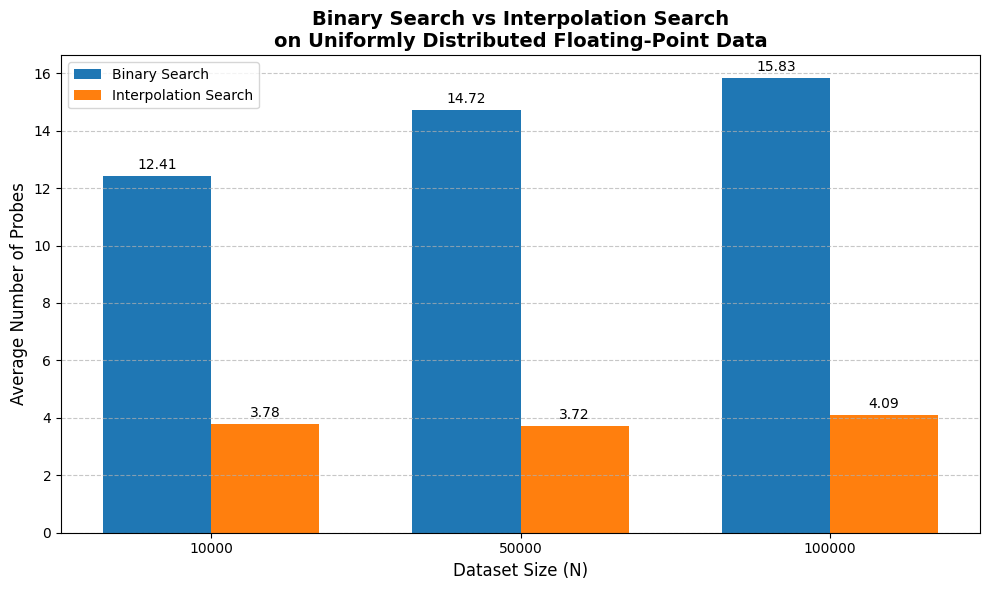


Chart saved as: search_comparison_chart.png


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt


def binary_search_float(arr, target):
    """
    Standard Binary Search for floating-point array.
    Returns (index, probes)
    """
    low = 0
    high = len(arr) - 1
    probes = 0

    while low <= high:
        probes += 1
        mid = (low + high) // 2

        if arr[mid] == target:
            return mid, probes
        elif arr[mid] < target:
            low = mid + 1
        else:
            high = mid - 1

    return -1, probes


def interpolation_search_float(arr, target):
    """
    Interpolation Search for floating-point array.
    Returns (index, probes)
    """
    low = 0
    high = len(arr) - 1
    probes = 0

    while low <= high and arr[low] <= target <= arr[high]:
        probes += 1

        # Prevent division by zero
        if arr[high] == arr[low]:
            if arr[low] == target:
                return low, probes
            break

        # Interpolation formula
        pos = low + int(
            ((high - low) / (arr[high] - arr[low]))
            * (target - arr[low])
        )

        # Clamp position within bounds
        pos = max(low, min(pos, high))

        if arr[pos] == target:
            return pos, probes

        elif arr[pos] < target:
            low = pos + 1

        else:
            high = pos - 1

    return -1, probes


# ---------------------------------------------------
# Main Program
# ---------------------------------------------------

if __name__ == "__main__":

    sizes = [10000, 50000, 100000]
    trials = 500

    avg_bs_probes = []
    avg_is_probes = []

    print("\nSEARCH PERFORMANCE COMPARISON")
    print("-" * 80)
    print(
        f"{'Dataset Size':<15} | "
        f"{'Avg Binary Search Probes':<25} | "
        f"{'Avg Interpolation Search Probes':<30}"
    )
    print("-" * 80)

    for size in sizes:

        bs_total = 0
        is_total = 0

        # Generate uniformly distributed floating-point values
        arr = np.sort(
            np.random.uniform(0.0, 1000.0, size)
        )

        for _ in range(trials):

            # Pick a target guaranteed to exist
            target = random.choice(arr)

            # Binary Search
            _, bs_probes = binary_search_float(arr, target)

            # Interpolation Search
            _, is_probes = interpolation_search_float(arr, target)

            bs_total += bs_probes
            is_total += is_probes

        avg_bs = bs_total / trials
        avg_is = is_total / trials

        avg_bs_probes.append(avg_bs)
        avg_is_probes.append(avg_is)

        print(
            f"{size:<15} | "
            f"{avg_bs:<25.2f} | "
            f"{avg_is:<30.2f}"
        )

    print("-" * 80)

    # ---------------------------------------------------
    # Visualization
    # ---------------------------------------------------

    x = np.arange(len(sizes))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))

    rects1 = ax.bar(
        x - width / 2,
        avg_bs_probes,
        width,
        label="Binary Search",
        color="#1f77b4"
    )

    rects2 = ax.bar(
        x + width / 2,
        avg_is_probes,
        width,
        label="Interpolation Search",
        color="#ff7f0e"
    )

    ax.set_title(
        "Binary Search vs Interpolation Search\n"
        "on Uniformly Distributed Floating-Point Data",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel("Dataset Size (N)", fontsize=12)
    ax.set_ylabel("Average Number of Probes", fontsize=12)

    ax.set_xticks(x)
    ax.set_xticklabels([str(size) for size in sizes])

    ax.legend()

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.7
    )

    # Add values on top of bars
    ax.bar_label(
        rects1,
        padding=3,
        fmt="%.2f"
    )

    ax.bar_label(
        rects2,
        padding=3,
        fmt="%.2f"
    )

    plt.tight_layout()

    # Save chart
    plt.savefig(
        "search_comparison_chart.png",
        dpi=300
    )

    # Display chart
    plt.show()

    print("\nChart saved as: search_comparison_chart.png")